In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [ ]:
mobile_sales = pd.read_csv('/content/drive/MyDrive/Time Series and Recsys data/time_series_2_data.csv')

In [ ]:
mobile_sales = mobile_sales.set_index('DATE')

In [ ]:
mobile_sales.index = pd.to_datetime(mobile_sales.index)

In [ ]:
mobile_sales = mobile_sales.asfreq('MS')

In [ ]:
train_x = mobile_sales.iloc[:193]
test_x = mobile_sales.iloc[193:]

In [ ]:
eval_df = test_x.copy()

In [ ]:
from statsmodels.tsa.holtwinters import Holt

# Fit Holt's Linear Trend (Double Exponential Smoothing)
holt_model = Holt(train_x['Sales']).fit(smoothing_level=0.5, smoothing_slope=0.5)

# Forecast next 24 steps
holt_pred = holt_model.forecast(steps=24)

/tmp/ipython-input-2352824328.py:4: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  holt_model = Holt(train_x['Sales']).fit(smoothing_level=0.2, smoothing_slope=0.1)
/usr/local/lib/python3.12/dist-packages/pandas/util/_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


In [ ]:
eval_df['des_pred'] = holt_pred

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error as mape
mape(eval_df['Sales'],eval_df['des_pred'])

0.08510708327047584

<Axes: xlabel='DATE'>

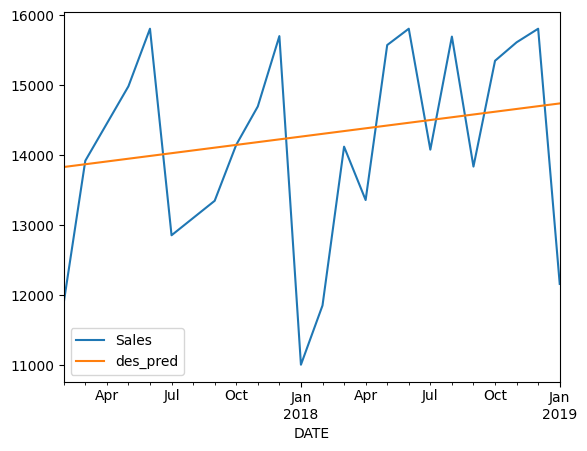

In [ ]:
eval_df.plot()

/tmp/ipython-input-1906042728.py:6: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  ).fit(smoothing_level=0.2, smoothing_slope=0.1, smoothing_seasonal=0.1, optimized=False)


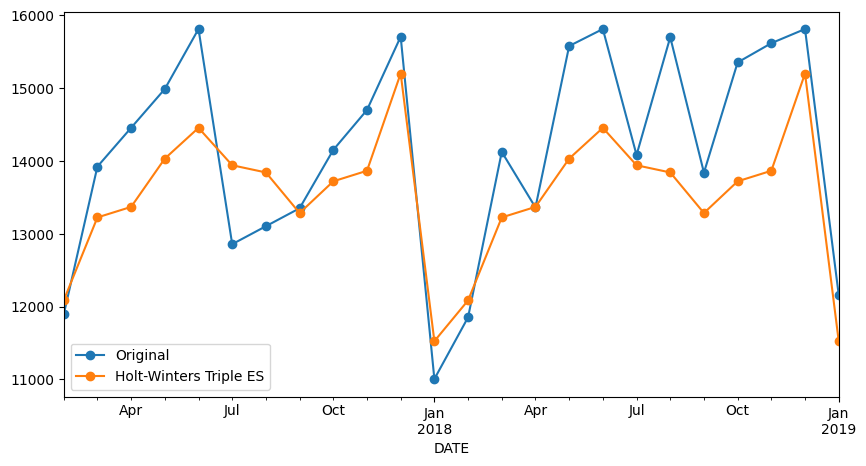

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw_model = ExponentialSmoothing(
    train_x['Sales'],
    seasonal='add',         # 'add' for additive seasonality, 'mul' for multiplicative
    seasonal_periods=12     # length of one seasonal cycle
).fit(smoothing_level=0.2, smoothing_slope=0.1, smoothing_seasonal=0.1, optimized=False)

# Forecast next 24 steps
hw_pred = hw_model.forecast(steps=24)

# Plot
plt.figure(figsize=(10,5))
test_x['Sales'].plot(label='Original', marker='o')
hw_pred.plot(label='Holt-Winters Triple ES', style='-o')
plt.legend()
plt.show()

In [ ]:
eval_df['tes_pred'] = hw_pred

In [ ]:
mape(eval_df['Sales'],eval_df['tes_pred'])

0.056240730615949495

In [ ]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(mobile_sales.Sales)

Sequence is not stationary


<Axes: xlabel='DATE'>

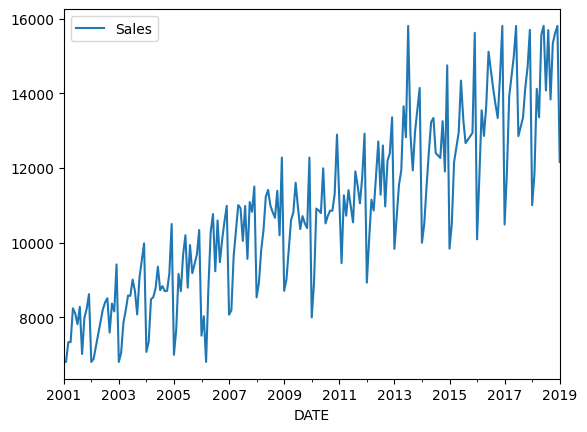

In [ ]:
mobile_sales.plot()

In [ ]:
sm.tsa.stattools.adfuller(train_x.Sales)[1]

np.float64(0.95816813237521)

<Axes: xlabel='DATE'>

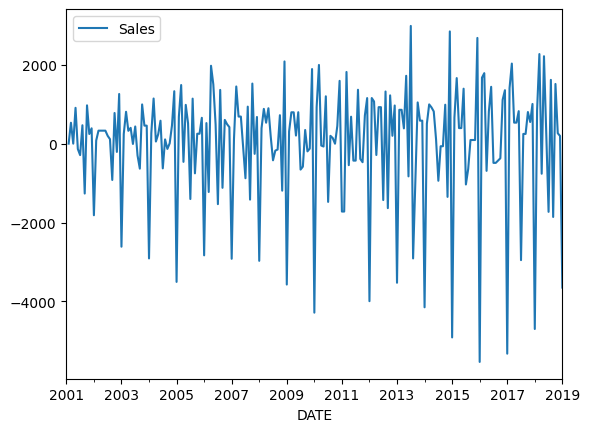

In [ ]:
mobile_sales.diff(1).plot()

In [ ]:
adf_test(mobile_sales.diff(1).dropna())

Sequence is stationary


<Axes: xlabel='DATE'>

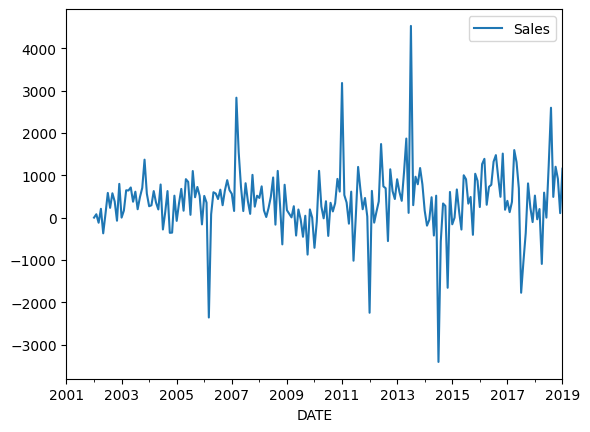

In [ ]:
mobile_sales.diff(12).plot()

<Figure size 800x400 with 0 Axes>

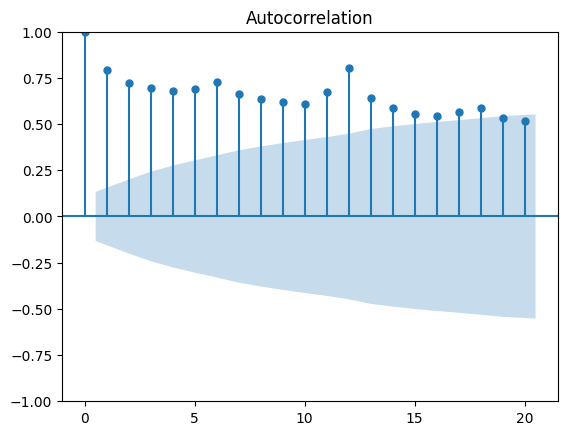

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf

plt.figure(figsize=(8,4))
plot_acf(mobile_sales.Sales, lags=20)
plt.show()

<Figure size 800x400 with 0 Axes>

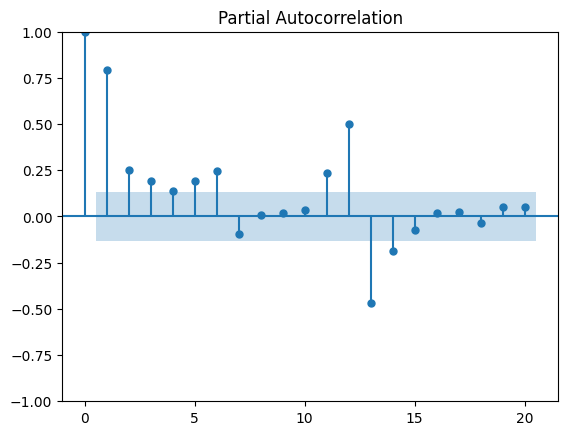

In [ ]:
plt.figure(figsize=(8,4))
plot_pacf(mobile_sales.Sales, lags=20)
plt.show()